In [ ]:
!export WANDB_API_KEY=
!export HF_TOKEN=
!echo $WANDB_API_KEY
!echo $HF_TOKEN

In [ ]:
import wandb
wandb.login(key="")
# 

In [1]:
# debug_forward.py
import torch
from transformers import MoshiForConditionalGeneration
from datasets import load_dataset, Audio
from moshi_dpo_collator import SpokenSwagMoshiCollator
import os
os.environ["HF_HOME"] = "/workspace/.hf_cache"   # adjust to your setup
os.makedirs(os.environ["HF_HOME"], exist_ok=True)

model = MoshiForConditionalGeneration.from_pretrained(
    "kmhf/hf-moshiko", torch_dtype=torch.bfloat16
).cuda()
model.eval()

ds = load_dataset("Bmingg/SpokenSwag-test-10", split="train")
ds = ds.cast_column("prompt",   Audio(sampling_rate=24000))
ds = ds.cast_column("chosen",   Audio(sampling_rate=24000))
ds = ds.cast_column("rejected", Audio(sampling_rate=24000))


collator = SpokenSwagMoshiCollator(
    mimi_model=model.audio_encoder,
    max_prompt_seconds=2.0,
    max_completion_seconds=2.0,
)
batch = collator([ds[0], ds[1]])
batch = {k: v.cuda() if torch.is_tensor(v) else v for k, v in batch.items()}

print("=== diagnostics ===")
print("text_ids:",  batch["chosen_input_ids"].min().item(),  batch["chosen_input_ids"].max().item())
print("moshi:",     batch["chosen_moshi_audio_codes"].min().item(), batch["chosen_moshi_audio_codes"].max().item())
print("user:",      batch["chosen_user_audio_codes"].min().item(),  batch["chosen_user_audio_codes"].max().item())
print("text vocab:",  model.config.vocab_size)
print("audio vocab:", model.config.audio_vocab_size)

with torch.no_grad():
    out = model(
        input_ids=batch["chosen_input_ids"],
        attention_mask=batch["chosen_attention_mask"],
        user_audio_codes=batch["chosen_user_audio_codes"],
        moshi_audio_codes=batch["chosen_moshi_audio_codes"],
        text_labels=batch["chosen_input_ids"],
        audio_labels=batch["chosen_moshi_audio_codes"],
        return_dict=True,
    )
print("forward OK, loss:", out.loss.item(), "depth_loss:", out.depth_loss.item())

OSError: [Errno 30] Read-only file system: '/workspace'

In [2]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("kmhf/hf-moshiko")
print(tokenizer.bos_token_id)

None


In [1]:
import numpy as np
from datasets import load_dataset
ds = load_dataset("slprl/SpokenSwag", split="train")
# don't cast_column — we just want durations
durations = []
for row in ds.select(range(2000)):  # sample
    for col in ("prompt", "chosen", "rejected"):
        arr = row[col]["array"]
        sr = row[col]["sampling_rate"]
        durations.append(len(arr) / sr)
print("p50:", np.percentile(durations, 50))
print("p95:", np.percentile(durations, 95))
print("p99:", np.percentile(durations, 99))
print("max:", max(durations))

Resolving data files:   0%|          | 0/58 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/58 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/56 [00:00<?, ?it/s]

p50: 3.875
p95: 7.3
p99: 9.400250000000005
max: 18.325


Streaming train split, sampling 5000 examples...


Resolving data files:   0%|          | 0/58 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/58 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

  ...500 examples
  ...1000 examples
  ...1500 examples
  ...2000 examples
  ...2500 examples
  ...3000 examples
  ...3500 examples
  ...4000 examples
  ...4500 examples

Collected 5000 examples.

--- prompt (5000 clips) ---
  p  50:   3.92s
  p  90:   6.50s
  p  95:   7.53s
  p  99:   9.75s
  p99.5:  11.00s
  mean :   4.29s
  max  :  18.32s
  > 10s:   43 (0.86%)
  > 15s:    5 (0.10%)

--- chosen (5000 clips) ---
  p  50:   3.90s
  p  90:   6.40s
  p  95:   7.30s
  p  99:   9.18s
  p99.5:  10.35s
  mean :   4.22s
  max  :  18.55s
  > 10s:   31 (0.62%)
  > 15s:    3 (0.06%)

--- rejected (5000 clips) ---
  p  50:   3.83s
  p  90:   6.20s
  p  95:   7.12s
  p  99:   9.25s
  p99.5:  10.05s
  mean :   4.16s
  max  :  18.73s
  > 10s:   27 (0.54%)
  > 15s:    2 (0.04%)

--- prompt + chosen (5000 clips) ---
  p  50:   7.95s
  p  90:  12.27s
  p  95:  13.88s
  p  99:  17.10s
  p99.5:  18.48s
  mean :   8.51s
  max  :  29.25s
  > 10s: 1216 (24.32%)
  > 15s:  143 (2.86%)

--- prompt + rejected (

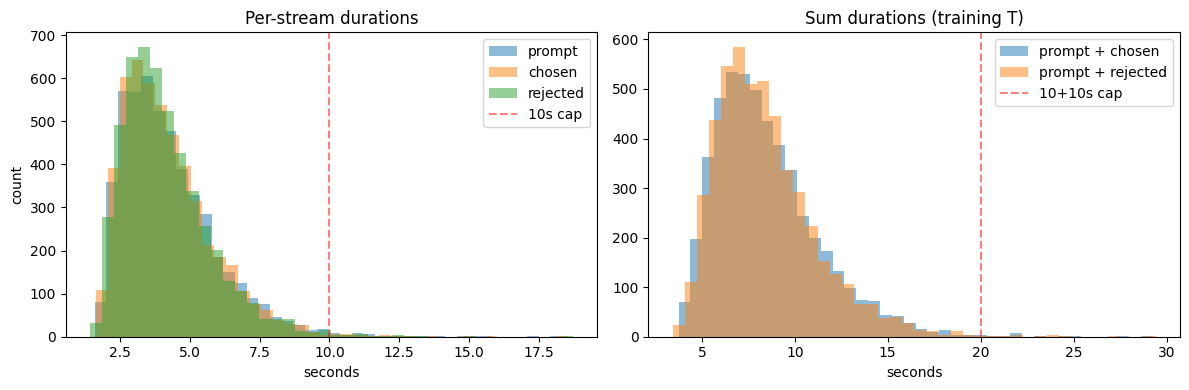

In [1]:
# %% [markdown]
# # SpokenSwag duration analysis
# 
# Streams the dataset (no disk usage), computes duration percentiles, and 
# simulates the effect of different truncation caps on training sequence length.

# %% Setup
import io
import numpy as np
import soundfile as sf
from datasets import load_dataset

N_SAMPLES = 5000
SPLIT = "train"

# %% Helper to extract duration regardless of audio field shape
def get_duration_seconds(audio_field) -> float:
    # torchcodec AudioDecoder — try metadata first (fast), then fall back to decoding
    if hasattr(audio_field, "metadata"):
        meta = audio_field.metadata
        if hasattr(meta, "num_frames") and hasattr(meta, "sample_rate"):
            return meta.num_frames / meta.sample_rate
    if hasattr(audio_field, "get_all_samples"):
        samples = audio_field.get_all_samples()
        return samples.data.shape[-1] / samples.sample_rate
    if isinstance(audio_field, dict) and "array" in audio_field:
        return len(audio_field["array"]) / audio_field["sampling_rate"]
    if isinstance(audio_field, dict) and "bytes" in audio_field:
        info = sf.info(io.BytesIO(audio_field["bytes"]))
        return info.frames / info.samplerate
    raise TypeError(f"Unexpected audio field: {type(audio_field)}, attrs: {dir(audio_field)}")

# %% Stream and collect durations
print(f"Streaming {SPLIT} split, sampling {N_SAMPLES} examples...")
ds = load_dataset("slprl/SpokenSwag", split=SPLIT, streaming=True)

prompt_durs, chosen_durs, rejected_durs = [], [], []

for i, row in enumerate(ds):
    if i >= N_SAMPLES:
        break
    if i % 500 == 0 and i > 0:
        print(f"  ...{i} examples")
    try:
        prompt_durs.append(get_duration_seconds(row["prompt"]))
        chosen_durs.append(get_duration_seconds(row["chosen"]))
        rejected_durs.append(get_duration_seconds(row["rejected"]))
    except Exception as e:
        print(f"  skipped row {i}: {e}")

print(f"\nCollected {len(prompt_durs)} examples.")

# %% Per-stream stats
def report(name, durations):
    d = np.array(durations)
    print(f"\n--- {name} ({len(d)} clips) ---")
    for pct in (50, 90, 95, 99, 99.5):
        print(f"  p{pct:>4}: {np.percentile(d, pct):>6.2f}s")
    print(f"  mean : {d.mean():>6.2f}s")
    print(f"  max  : {d.max():>6.2f}s")
    print(f"  > 10s: {(d > 10).sum():>4} ({100*(d>10).mean():.2f}%)")
    print(f"  > 15s: {(d > 15).sum():>4} ({100*(d>15).mean():.2f}%)")

report("prompt", prompt_durs)
report("chosen", chosen_durs)
report("rejected", rejected_durs)

# %% Combined stats (what actually drives memory in training)
p_arr = np.array(prompt_durs)
c_arr = np.array(chosen_durs)
r_arr = np.array(rejected_durs)
pc = p_arr + c_arr
pr = p_arr + r_arr
combined = np.concatenate([pc, pr])

report("prompt + chosen", pc)
report("prompt + rejected", pr)

# %% Sequence-length view (Mimi runs at 12.5 Hz)
print("\n--- T_frames at 12.5 Hz, no truncation ---")
for pct in (50, 95, 99):
    s = np.percentile(combined, pct)
    print(f"  p{pct}: {s*12.5:>5.0f} frames ({s:.1f}s)")
print(f"  max: {combined.max()*12.5:>5.0f} frames ({combined.max():.1f}s)")

# %% Truncation simulation
print("\n--- Truncation effect on T (frames) ---")
print(f"{'p_cap':>6} {'c_cap':>6} {'T_p50':>6} {'T_p95':>6} {'T_p99':>6} {'T_max':>6}")
for p_cap, c_cap in [(None, None), (10, 10), (8, 10), (5, 10), (8, 8), (5, 5)]:
    p_capped = np.minimum(p_arr, p_cap) if p_cap else p_arr
    c_capped = np.minimum(c_arr, c_cap) if c_cap else c_arr
    r_capped = np.minimum(r_arr, c_cap) if c_cap else r_arr
    T = np.concatenate([p_capped + c_capped, p_capped + r_capped]) * 12.5
    p_str = f"{p_cap}s" if p_cap else "none"
    c_str = f"{c_cap}s" if c_cap else "none"
    print(f"{p_str:>6} {c_str:>6} {np.percentile(T,50):>6.0f} "
          f"{np.percentile(T,95):>6.0f} {np.percentile(T,99):>6.0f} {T.max():>6.0f}")

# %% Optional: histogram visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(prompt_durs, bins=40, alpha=0.5, label="prompt")
axes[0].hist(chosen_durs, bins=40, alpha=0.5, label="chosen")
axes[0].hist(rejected_durs, bins=40, alpha=0.5, label="rejected")
axes[0].axvline(10, color="red", linestyle="--", alpha=0.5, label="10s cap")
axes[0].set_xlabel("seconds")
axes[0].set_ylabel("count")
axes[0].set_title("Per-stream durations")
axes[0].legend()

axes[1].hist(pc, bins=40, alpha=0.5, label="prompt + chosen")
axes[1].hist(pr, bins=40, alpha=0.5, label="prompt + rejected")
axes[1].axvline(20, color="red", linestyle="--", alpha=0.5, label="10+10s cap")
axes[1].set_xlabel("seconds")
axes[1].set_title("Sum durations (training T)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [3]:
import torch
import torch.nn.functional as F

# -----------------------------
# Device setup: CUDA > MPS > CPU
# -----------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Use float32 for correctness testing.
# bf16/fp16 can introduce larger numerical differences due to different kernels.
dtype = torch.float32

print(f"Using device: {device}, dtype: {dtype}")


# -----------------------------
# Original HF-style implementation
# -----------------------------
def original_forward(weight, x, layer_idx=None):
    """
    Exact math from HF MoshiFlexibleLinear.forward.

    weight: [num_layers, output_dim, input_dim]
    x:      [B, S, input_dim]
    """
    selected_weights = (
        torch.index_select(weight, 0, layer_idx)
        if layer_idx is not None
        else weight
    )

    # [K, O, D] -> [1, K, D, O]
    selected_weights = selected_weights.transpose(1, 2)[None, :, :, :]

    # [B, S, D] -> [B, S, 1, D]
    # matmul broadcasts S/K if needed.
    y = torch.matmul(x[:, :, None, :], selected_weights)

    return y.squeeze(2)


# -----------------------------
# Patched memory-safe implementation
# -----------------------------
def patched_forward(weight, x, layer_idx=None):
    """
    Memory-safe implementation equivalent to the patch.

    Supports:
      Case A: x = [B, K, D], weights = [K, O, D] -> [B, K, O]
      Case B: x = [B, 1, D], weights = [K, O, D] -> [B, K, O]
    """
    if x.dim() != 3:
        raise ValueError(f"Expected x to be [B, S, D], got {tuple(x.shape)}")

    B, S, D = x.shape

    if layer_idx is None:
        weights = weight
    else:
        layer_idx = layer_idx.to(device=weight.device, dtype=torch.long)
        weights = torch.index_select(weight, 0, layer_idx)

    K, O, D_weight = weights.shape
    assert D == D_weight, (x.shape, weights.shape)

    # Case A: one x vector per selected codebook/layer.
    if S == K:
        outs = [F.linear(x[:, i, :], weights[i]) for i in range(K)]
        return torch.stack(outs, dim=1)

    # Case B: one x vector broadcast to all selected codebooks/layers.
    if S == 1:
        x0 = x[:, 0, :]
        outs = [F.linear(x0, weights[i]) for i in range(K)]
        return torch.stack(outs, dim=1)

    raise ValueError(
        f"Unsupported shape: x={tuple(x.shape)}, weights={tuple(weights.shape)}"
    )


# -----------------------------
# Equivalence test helper
# -----------------------------
def check_case(name, x_shape, layer_idx, atol=1e-5):
    torch.manual_seed(0)

    num_layers = 8
    output_dim = 11
    input_dim = x_shape[-1]

    weight0 = torch.randn(
        num_layers, output_dim, input_dim,
        device=device,
        dtype=dtype,
        requires_grad=True,
    )
    weight1 = weight0.detach().clone().requires_grad_(True)

    x0 = torch.randn(*x_shape, device=device, dtype=dtype, requires_grad=True)
    x1 = x0.detach().clone().requires_grad_(True)

    if layer_idx is not None:
        layer_idx_tensor = torch.tensor(layer_idx, device=device, dtype=torch.long)
    else:
        layer_idx_tensor = None

    y0 = original_forward(weight0, x0, layer_idx_tensor)
    y1 = patched_forward(weight1, x1, layer_idx_tensor)

    max_out_diff = (y0.detach().cpu() - y1.detach().cpu()).abs().max().item()
    same_shape = y0.shape == y1.shape

    # Nontrivial scalar loss for gradient check.
    loss0 = (y0.float() ** 2).mean()
    loss1 = (y1.float() ** 2).mean()

    loss0.backward()
    loss1.backward()

    max_x_grad_diff = (
        x0.grad.detach().cpu() - x1.grad.detach().cpu()
    ).abs().max().item()

    max_w_grad_diff = (
        weight0.grad.detach().cpu() - weight1.grad.detach().cpu()
    ).abs().max().item()

    passed = (
        same_shape
        and max_out_diff < atol
        and max_x_grad_diff < atol
        and max_w_grad_diff < atol
    )

    print(f"\n{name}")
    print(f"  y0 shape: {tuple(y0.shape)}")
    print(f"  y1 shape: {tuple(y1.shape)}")
    print(f"  same shape: {same_shape}")
    print(f"  max output diff: {max_out_diff:.3e}")
    print(f"  max x grad diff: {max_x_grad_diff:.3e}")
    print(f"  max weight grad diff: {max_w_grad_diff:.3e}")
    print(f"  PASSED: {passed}")

    assert passed, f"{name} failed"


# -----------------------------
# Run tests
# -----------------------------
B = 5
K = 8
D = 17

check_case(
    name="Case 1: layer_idx=None, x=[B,K,D]",
    x_shape=(B, K, D),
    layer_idx=None,
)

check_case(
    name="Case 2: layer_idx=[0..7], x=[B,K,D]",
    x_shape=(B, K, D),
    layer_idx=list(range(K)),
)

check_case(
    name="Case 3: layer_idx=[0..7], x=[B,1,D] broadcast",
    x_shape=(B, 1, D),
    layer_idx=list(range(K)),
)

check_case(
    name="Case 4: layer_idx subset, x=[B,L,D]",
    x_shape=(B, 3, D),
    layer_idx=[0, 3, 7],
)

check_case(
    name="Case 5: layer_idx subset, x=[B,1,D] broadcast",
    x_shape=(B, 1, D),
    layer_idx=[0, 3, 7],
)

print("\n✅ All MoshiFlexibleLinear patch equivalence tests passed.")

Using device: mps, dtype: torch.float32

Case 1: layer_idx=None, x=[B,K,D]
  y0 shape: (5, 8, 11)
  y1 shape: (5, 8, 11)
  same shape: True
  max output diff: 1.907e-06
  max x grad diff: 5.960e-08
  max weight grad diff: 5.960e-08
  PASSED: True

Case 2: layer_idx=[0..7], x=[B,K,D]
  y0 shape: (5, 8, 11)
  y1 shape: (5, 8, 11)
  same shape: True
  max output diff: 1.907e-06
  max x grad diff: 5.960e-08
  max weight grad diff: 5.960e-08
  PASSED: True

Case 3: layer_idx=[0..7], x=[B,1,D] broadcast
  y0 shape: (5, 8, 11)
  y1 shape: (5, 8, 11)
  same shape: True
  max output diff: 1.013e-06
  max x grad diff: 7.451e-08
  max weight grad diff: 2.049e-08
  PASSED: True

Case 4: layer_idx subset, x=[B,L,D]
  y0 shape: (5, 3, 11)
  y1 shape: (5, 3, 11)
  same shape: True
  max output diff: 9.537e-07
  max x grad diff: 5.960e-08
  max weight grad diff: 5.960e-08
  PASSED: True

Case 5: layer_idx subset, x=[B,1,D] broadcast
  y0 shape: (5, 3, 11)
  y1 shape: (5, 3, 11)
  same shape: True
  ma